In [1]:
import pandas as pd

df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
print(df.shape)
print(df.columns.tolist())


(114000, 21)
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [3]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [4]:
df = df.dropna()
print(df.shape)

(113999, 21)


In [5]:
correlation = df[['popularity', 'danceability', 'energy', 'loudness', 'acousticness', 'valence', 'tempo']].corr()
print(correlation['popularity'].sort_values(ascending=False))

popularity      1.000000
loudness        0.050420
danceability    0.035444
tempo           0.013212
energy          0.001053
acousticness   -0.025458
valence        -0.040522
Name: popularity, dtype: float64


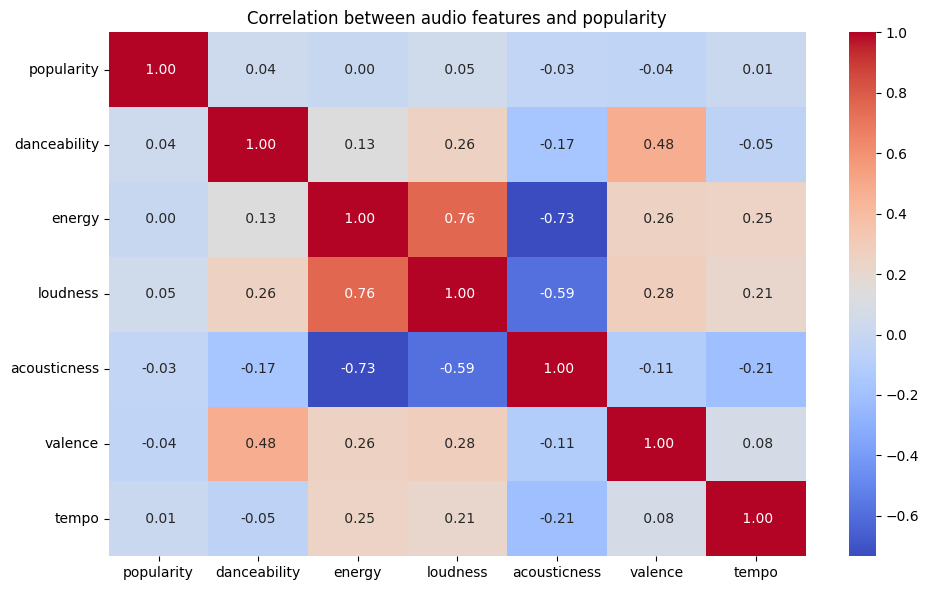

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(correlation, annot=True, fmt=' .2f', cmap='coolwarm')
plt.title('Correlation between audio features and popularity')
plt.tight_layout()
plt.show()

In [7]:
df.groupby('track_genre')[['energy', 'valence', 'danceability', 'popularity']].mean().sort_values('popularity', ascending=False).head(10)

,energy,valence,danceability,popularity
track_genre,,,,
pop-film,0.604562,0.529253,0.597146,59.283000
k-pop,0.675747,0.556738,0.647879,56.952953
chill,0.426723,0.403770,0.664346,53.651000
sad,0.462470,0.422050,0.692378,52.379000
grunge,0.803290,0.400373,0.457062,49.594000
indian,0.567121,0.463024,0.592273,49.539000
anime,0.674108,0.434463,0.537451,48.772000
emo,0.669967,0.441135,0.599321,48.128000
sertanejo,0.710391,0.619325,0.591647,47.866000


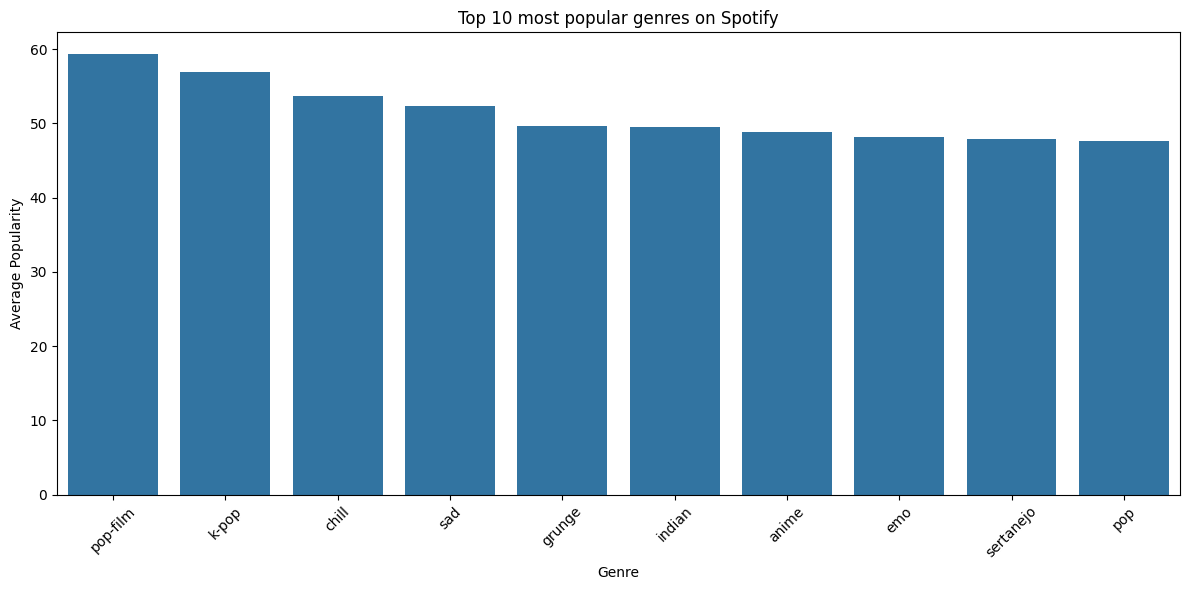

In [8]:
genre_stats = df.groupby('track_genre')[['energy', 'valence', 'danceability', 'popularity']].mean().sort_values('popularity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_stats, x=genre_stats.index, y='popularity')
plt.title('Top 10 most popular genres on Spotify')
plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

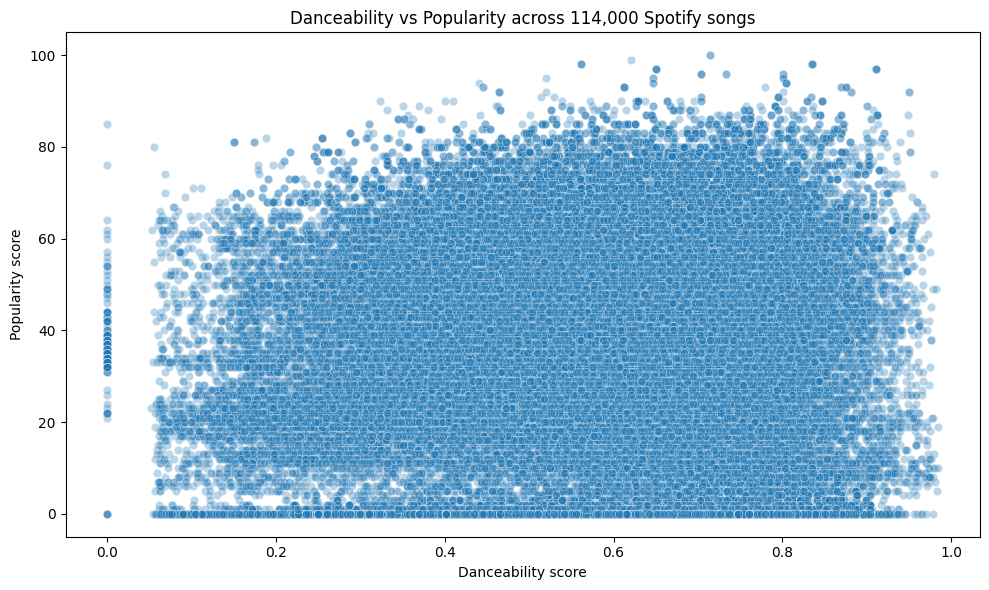

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='danceability', y='popularity', alpha=0.3)
plt.title('Danceability vs Popularity across 114,000 Spotify songs')
plt.xlabel('Danceability score')
plt.ylabel('Popularity score')
plt.tight_layout()
plt.show()


# Spotify tracks analysis

I wanted to find out what actually makes a song popular on spotify, does it have to be danceable? Loud? Happy? It turns out that the answer is more interesting than I expected

## What I used
- Python, pandas, matplotlib, seaborn
- Dataset: 114,000 Spotify tracks from Kaggle

## What I found
1. **How a song sounds barely predicts how popular it gets** 
none of the audio features had a strong correlation with popularity. The biggest factor was loudness and even that was 0.05. Stuff like artist fame and playlist placement probably matters way more.

2. **Pop-film and K-pop are the most popular genres**
Soundtrack music from movies and TV ranked #1, Pop-film and K-pop came in at #2 with the highest danceability of any genre.

3. **Sad songs actually do better than happy ones**
I expected happy upbeat songs to perform best but the data showed the opposite. Melancholic songs consistently score higher on Spotify.

4. **High energy doesn't mean popular**
grunge had the most energy of any genre but only ranked 5th in popularity. Energy alone doesn't make a hit.

##  Summary
I cleaned and analyzed 114,000 rows of real data, built a correlation heatmap, a genre comparison bar chart, and a scatter plot of every song in the dataset.